# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [3]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [27]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()
df.shape


(9994, 21)

In [28]:
list(df.columns)

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [29]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [30]:
list(df.columns)

['row_id',
 'order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country',
 'city',
 'state',
 'postal_code',
 'region',
 'product_id',
 'category',
 'sub-category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit']

### Double check some datatypes, and for nulls and duplicates:

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   object 
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   object 
 4   ship_mode      9994 non-null   object 
 5   customer_id    9994 non-null   object 
 6   customer_name  9994 non-null   object 
 7   segment        9994 non-null   object 
 8   country        9994 non-null   object 
 9   city           9994 non-null   object 
 10  state          9994 non-null   object 
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   object 
 13  product_id     9994 non-null   object 
 14  category       9994 non-null   object 
 15  sub-category   9994 non-null   object 
 16  product_name   9994 non-null   object 
 17  sales          9994 non-null   float64
 18  quantity

In [45]:
df.columns = df.columns.str.strip()

In [46]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [47]:
df[['order_date', 'ship_date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_date  3974 non-null   datetime64[ns]
 1   ship_date   3878 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 156.3 KB


In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df.isnull().sum()

row_id              0
order_id            0
order_date       6020
ship_date        6116
ship_mode           0
customer_id         0
customer_name       0
segment             0
country             0
city                0
state               0
postal_code         0
region              0
product_id          0
category            0
sub-category        0
product_name        0
sales               0
quantity            0
discount            0
profit              0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [51]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    errors='coerce',
    infer_datetime_format=True
)

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    errors='coerce',
    infer_datetime_format=True
)

C:\Users\opiej\AppData\Local\Temp\ipykernel_6564\3313110715.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['order_date'] = pd.to_datetime(
C:\Users\opiej\AppData\Local\Temp\ipykernel_6564\3313110715.py:7: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['ship_date'] = pd.to_datetime(


In [54]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True )

In [56]:
df.dtypes

row_id                    int64
order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode                object
customer_id              object
customer_name            object
segment                  object
country                  object
city                     object
state                    object
postal_code               int64
region                   object
product_id               object
category                 object
sub-category             object
product_name             object
sales                   float64
quantity                  int64
discount                float64
profit                  float64
dtype: object

In [57]:
df[['sales', 'quantity', 'discount', 'profit']].describe()

,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [59]:
df.segment.unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [60]:
df.rename(columns={"segment":"customer_category"}, inplace=True)
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,customer_category,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2013-152156,2013-09-11,2013-12-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-09-11,2013-12-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,NaT,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [61]:
(df['profit'] < 0).sum()  
df['discount'].value_counts().sort_index()

discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [77]:
import sqlite3
conn = sqlite3.connect('../data/superstore.db')
customers_df = (
    df[['customer_id','customer_name','customer_category','city','state','region','postal_code']]
    .drop_duplicates()
    .rename(columns={'postal_code': 'zipcode'})
)

products_df = (
    df[['product_id','category','sub-category','product_name']]
    .drop_duplicates()
    .rename(columns={'sub-category': 'subcategory'})
)

orders_df = (
    df[['order_id','order_date','ship_date','ship_mode','customer_id']]
    .drop_duplicates()
)

order_details_df = df[['order_id','product_id','sales','quantity','discount','profit']]

customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')

conn.commit()
conn.close()

After I did some EDA and Wrangling, the above no longer worked, so below is mine:

In [78]:
print(df.shape)
print(df.columns.tolist())

(9994, 21)
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'customer_category', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [74]:
import sqlite3

conn = sqlite3.connect('../data/superstore.db')

Customer Table

In [80]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv', index=False)

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [ ]:
import sqlite3
import pandas as pd


conn = sqlite3.connect("../data/superstore.db")


pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,customers
1,products
2,orders
3,order_details


In [92]:
query1 = """
SELECT
    c.customer_category,
    ROUND(SUM(od.sales), 2)  AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o
    ON od.order_id = o.order_id
JOIN customers c
    ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [93]:
query2 = """
SELECT
    c.customer_id,
    c.customer_name,
    ROUND(SUM(od.sales), 2) AS total_sales
FROM order_details od
JOIN orders o
    ON od.order_id = o.order_id
JOIN customers c
    ON o.customer_id = c.customer_id
GROUP BY c.customer_id, c.customer_name
ORDER BY total_sales DESC
LIMIT 10;
"""

result2 = pd.read_sql(query2, conn)
result2

,customer_id,customer_name,total_sales
0,KL-16645,Ken Lonsdale,155927.52
1,SE-20110,Sanjit Engle,134303.82
2,CL-12565,Clay Ludtke,130566.55
3,AB-10105,Adrian Barton,130262.14
4,SC-20095,Sanjit Chand,127281.01
5,SM-20320,Sean Miller,125215.25
6,EH-13765,Edward Hooks,123730.56
7,GT-14710,Greg Tran,118201.20
8,SV-20365,Seth Vernon,114709.50
9,JL-15835,John Lee,107799.15


### Which product categories and subcategories are the most profitable overall?

In [94]:
query3 = """
SELECT
    p.category,
    p.subcategory,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN products p
    ON od.product_id = p.product_id
GROUP BY p.category, p.subcategory
ORDER BY total_profit DESC;
"""

result3 = pd.read_sql(query3, conn)
result3

,category,subcategory,total_profit
0,Technology,Copiers,55617.82
1,Technology,Accessories,48359.05
2,Technology,Phones,46936.19
3,Office Supplies,Paper,36994.53
4,Office Supplies,Binders,30373.20
5,Furniture,Chairs,26707.65
6,Office Supplies,Storage,21408.70
7,Office Supplies,Appliances,18514.49
8,Furniture,Furnishings,14569.59
9,Office Supplies,Envelopes,6964.18


### What is the average discount given per category?

In [95]:
query4 = """
SELECT
    p.category,
    ROUND(AVG(od.discount), 4) AS avg_discount
FROM order_details od
JOIN products p
    ON od.product_id = p.product_id
GROUP BY p.category
ORDER BY avg_discount DESC;
"""

result4 = pd.read_sql(query4, conn)
result4

,category,avg_discount
0,Furniture,0.1725
1,Office Supplies,0.1570
2,Technology,0.1330


### Which states or regions contribute the most to total sales?

In [ ]:
query5 = """
SELECT
    c.state,
    ROUND(SUM(od.sales), 2) AS total_sales
FROM order_details od
JOIN orders o
    ON od.order_id = o.order_id
JOIN customers c
    ON o.customer_id = c.customer_id
GROUP BY c.state
ORDER BY total_sales DESC;
"""

result5 = pd.read_sql(query5, conn)
result5

In [96]:
query5 = """
SELECT
    c.region,
    ROUND(SUM(od.sales), 2) AS total_sales
FROM order_details od
JOIN orders o
    ON od.order_id = o.order_id
JOIN customers c
    ON o.customer_id = c.customer_id
GROUP BY c.region
ORDER BY total_sales DESC;
"""

result5 = pd.read_sql(query5, conn)
result5

,region,total_sales
0,West,5306522.06
1,East,4522990.06
2,Central,3853691.95
3,South,2706437.54


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [97]:
query6 = """
SELECT
    COUNT(*) AS late_orders
FROM orders
WHERE date(ship_date) > date(order_date, '+3 day');
"""

result6 = pd.read_sql(query6, conn)
result6

,late_orders
0,1230


In [98]:
query6_check = """
SELECT
    order_id,
    order_date,
    ship_date
FROM orders
WHERE date(ship_date) > date(order_date, '+3 day')
ORDER BY date(order_date);
"""

pd.read_sql(query6_check, conn).head(20)

,order_id,order_date,ship_date
0,CA-2011-115161,2011-01-02 00:00:00,2011-03-02 00:00:00
1,CA-2011-104269,2011-01-03 00:00:00,2011-06-03 00:00:00
2,US-2011-143707,2011-01-03 00:00:00,2011-05-03 00:00:00
3,CA-2011-113880,2011-01-03 00:00:00,2011-05-03 00:00:00
4,CA-2011-131009,2011-01-03 00:00:00,2011-05-03 00:00:00
5,CA-2011-168312,2011-01-03 00:00:00,2011-07-03 00:00:00
6,US-2011-157021,2011-01-04 00:00:00,2011-06-04 00:00:00
7,CA-2011-138359,2011-01-04 00:00:00,2011-06-04 00:00:00
8,CA-2011-131926,2011-01-06 00:00:00,2011-06-06 00:00:00
9,CA-2011-111003,2011-01-06 00:00:00,2011-06-06 00:00:00


### Which month or year had the highest total sales?

In [99]:
query7 = """
SELECT
    strftime('%Y-%m', o.order_date) AS year_month,
    ROUND(SUM(od.sales), 2) AS total_sales
FROM order_details od
JOIN orders o
    ON od.order_id = o.order_id
GROUP BY year_month
ORDER BY total_sales DESC
LIMIT 1;
"""

result7 = pd.read_sql(query7, conn)
result7

,year_month,total_sales
0,None,1411741.22


In [100]:
query7 = """
SELECT
    strftime('%Y-%m', o.order_date) AS year_month,
    ROUND(SUM(od.sales), 2) AS total_sales
FROM order_details od
JOIN orders o
    ON od.order_id = o.order_id
GROUP BY year_month
ORDER BY total_sales DESC
LIMIT 1;
"""

result7 = pd.read_sql(query7, conn)
result7

,year_month,total_sales
0,None,1411741.22


### What are the most frequently ordered products?

In [101]:
query8 = """
SELECT
    p.product_name,
    SUM(od.quantity) AS total_units_sold
FROM order_details od
JOIN products p
    ON od.product_id = p.product_id
GROUP BY p.product_name
ORDER BY total_units_sold DESC
LIMIT 10;
"""

result8 = pd.read_sql(query8, conn)
result8

,product_name,total_units_sold
0,Staples,876
1,Logitech P710e Mobile Speakerphone,75
2,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive,75
3,KI Adjustable-Height Table,74
4,Storex Dura Pro Binders,71
5,Avery Non-Stick Binders,71
6,Xerox 1908,70
7,Xerox 1881,70
8,GBC Premium Transparent Covers with Diagonal L...,67
9,"Situations Contoured Folding Chairs, 4/Set",64


### Which customers placed more than 5 orders total?

In [102]:
query9 = """
SELECT
    c.customer_id,
    c.customer_name,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
GROUP BY c.customer_id, c.customer_name
HAVING COUNT(DISTINCT o.order_id) > 5
ORDER BY total_orders DESC;
"""

result9 = pd.read_sql(query9, conn)
result9

,customer_id,customer_name,total_orders
0,EP-13915,Emily Phan,17
1,CK-12205,Chloris Kastensmidt,13
2,EA-14035,Erin Ashbrook,13
3,JE-15745,Joel Eaton,13
4,NS-18640,Noel Staavos,13
...,...,...,...
459,TS-21370,Todd Sumrall,6
460,TS-21505,Tony Sayre,6
461,VB-21745,Victoria Brennan,6
462,VD-21670,Valerie Dominguez,6


### What’s the profit margin (profit ÷ sales) by category or segment?

In [103]:
query10 = """
SELECT
    p.category,
    ROUND(SUM(od.sales), 2)  AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit,
    ROUND(
        CASE 
            WHEN SUM(od.sales) = 0 THEN 0
            ELSE SUM(od.profit) * 1.0 / SUM(od.sales)
        END
    , 4) AS profit_margin
FROM order_details od
JOIN products p
    ON od.product_id = p.product_id
GROUP BY p.category
ORDER BY profit_margin DESC;
"""

result10 = pd.read_sql(query10, conn)
result10

,category,total_sales,total_profit,profit_margin
0,Technology,893633.28,153415.70,0.1717
1,Office Supplies,736748.59,126113.35,0.1712
2,Furniture,764284.65,20098.89,0.0263


In [105]:
query10 = """
SELECT
    c.customer_category,
    ROUND(SUM(od.sales), 2)  AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit,
    ROUND(
        CASE 
            WHEN SUM(od.sales) = 0 THEN 0
            ELSE SUM(od.profit) * 1.0 / SUM(od.sales)
        END
    , 4) AS profit_margin
FROM order_details od
JOIN orders o
    ON od.order_id = o.order_id
JOIN customers c
    ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY profit_margin DESC;
"""

result10 = pd.read_sql(query10, conn)
result10

,customer_category,total_sales,total_profit,profit_margin
0,Home Office,2964459.36,434344.01,0.1465
1,Corporate,5044899.83,660287.69,0.1309
2,Consumer,8380282.43,973085.86,0.1161


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

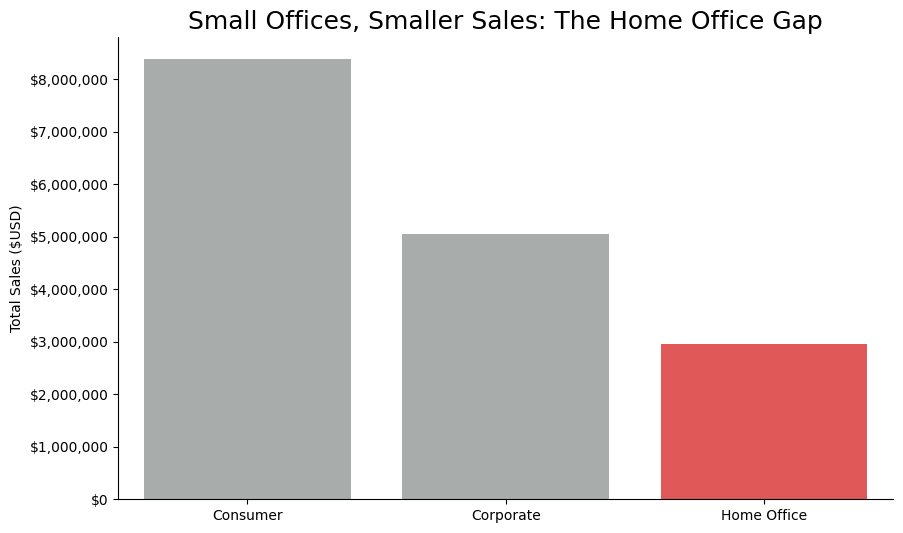

In [104]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


C:\Users\opiej\AppData\Local\Temp\ipykernel_6564\125853175.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


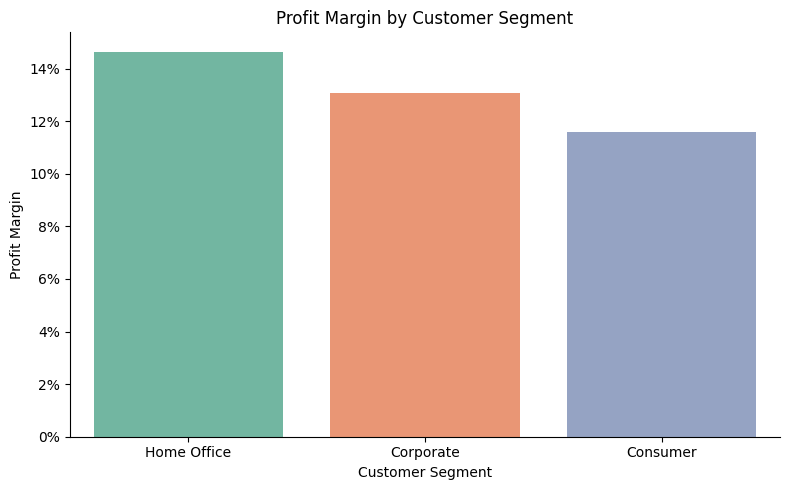

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.barplot(
    data=result10,
    x='customer_category',
    y='profit_margin',
    palette='Set2'
)

plt.title('Profit Margin by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Profit Margin')


plt.gca().yaxis.set_major_formatter(
    lambda x, _: f'{x:.0%}'
)

sns.despine()
plt.tight_layout()
plt.show()

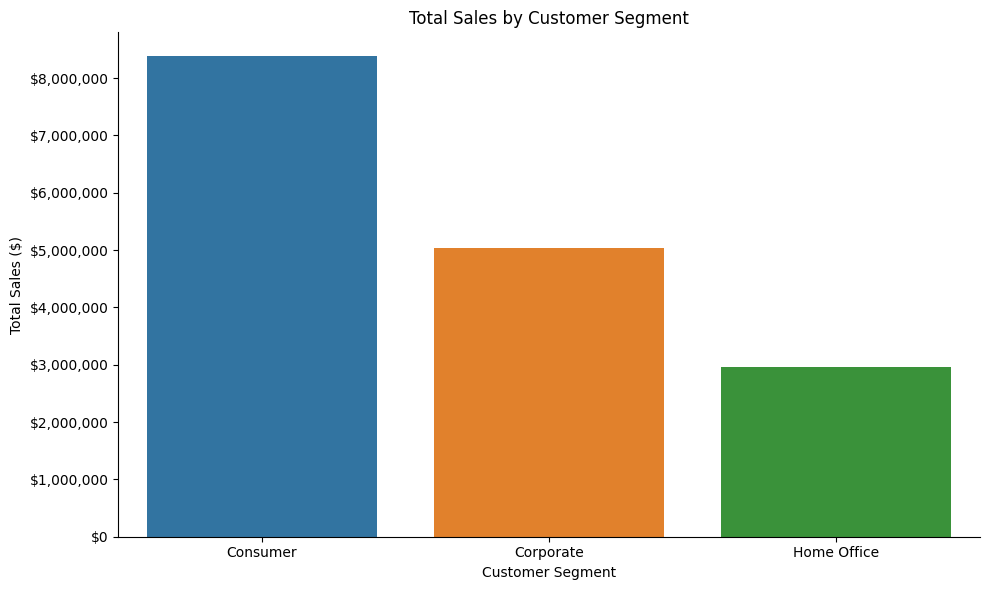

In [108]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=result1,
    x='customer_category',
    y='total_sales',
    hue='customer_category',
    legend=False
)

plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales ($)')

plt.gca().yaxis.set_major_formatter(
    lambda x, _: f'${x:,.0f}'
)

sns.despine()
plt.tight_layout()
plt.show()

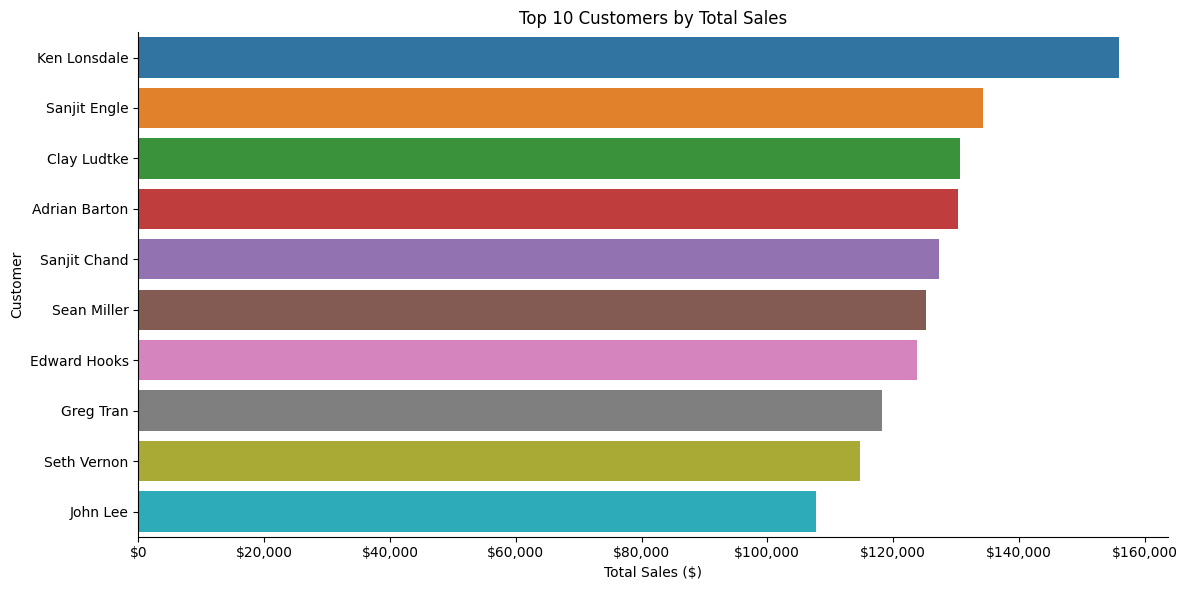

In [109]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=result2,
    x='total_sales',
    y='customer_name',
    hue='customer_name',
    legend=False
)

plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer')

plt.gca().xaxis.set_major_formatter(
    lambda x, _: f'${x:,.0f}'
)

sns.despine()
plt.tight_layout()
plt.show()

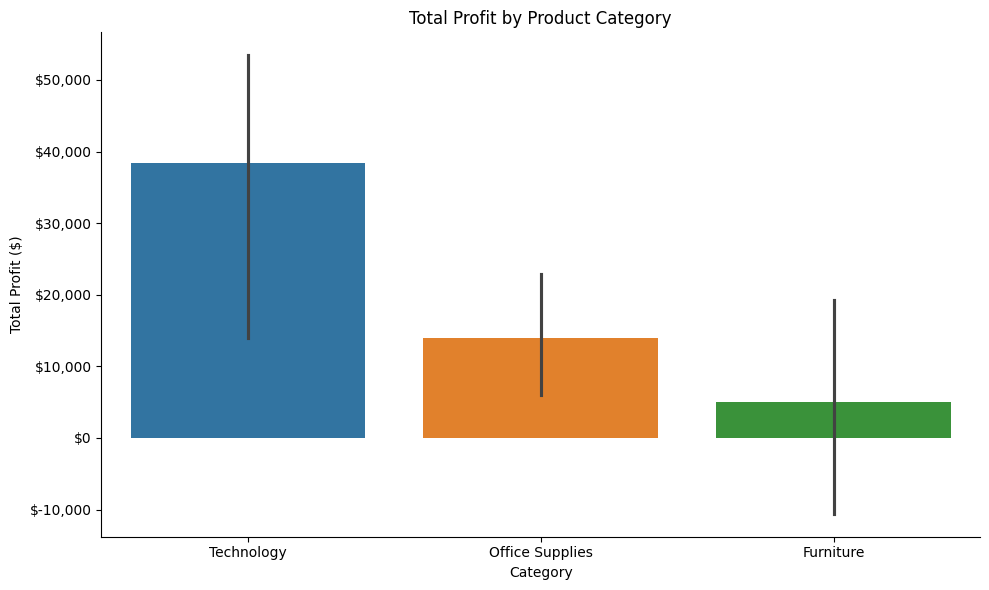

In [110]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=result3,
    x='category',
    y='total_profit',
    hue='category',
    legend=False
)

plt.title('Total Profit by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')

plt.gca().yaxis.set_major_formatter(
    lambda x, _: f'${x:,.0f}'
)

sns.despine()
plt.tight_layout()
plt.show()